# Week 3 Homework - Wine Classification

## 3.0 Task: Data Loading

In [219]:
import pandas as pd
import numpy as np

In [220]:
import os
print(os.getcwd())

c:\Users\Leon Lorenz\OneDrive\Desktop\Uni TUM Master\Z_LMU\SoSe26\AppliedML\weeks\week3_classification


In [221]:
df_original = pd.read_csv("wine/wine.data", names=['Class','Alcohol', 'Malic acid','Ash', 'Alcalinity of ash', 'Magnesium',
               'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 
                'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline'])
df_original.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 3.1 Task: Assigning class labels

In [222]:
df_original["Class"].value_counts()

Class
2    71
1    59
3    48
Name: count, dtype: int64

In [223]:
df_original.shape

(178, 14)

In [224]:
df_binary = df_original[df_original["Class"] != 3]
## or df_binary = df_original[(     df_original["Class"] == 1) |     (df_original["Class"] == 2)] -- ChatGPT Solution
df_binary["Class"].value_counts()


Class
2    71
1    59
Name: count, dtype: int64

## 3.2 Task: Shuffle and split the data

Shuffle the data and separate it into train and test subsets. The train set should constitute 80% of the data.

In [225]:
def  my_train_test_split(df, training_data_fraction, shuffle=True):
    if shuffle:
        _df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    else:
        _df = df
    
    train_df = _df.iloc[:int(training_data_fraction*len(_df)),:]
    test_df = _df.iloc[int(training_data_fraction*len(_df)):,:]
    
    return train_df, test_df


training_data_fraction = .8

train_df, test_df = my_train_test_split(df_binary, training_data_fraction)

# Check if the split is correct
# print(len(df_binary))
# print(len(train_df))
# print(len(test_df)) 

In [226]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_binary,
    train_size=training_data_fraction,
    random_state=42
)

## import sklearn
## sklearn_train_df, sklearn_test_df = sklearn.model_selection.train_test_split(df_binary, train_size=training_data_fraction, random_state=42)


## 3.3 Task: Visualizing 

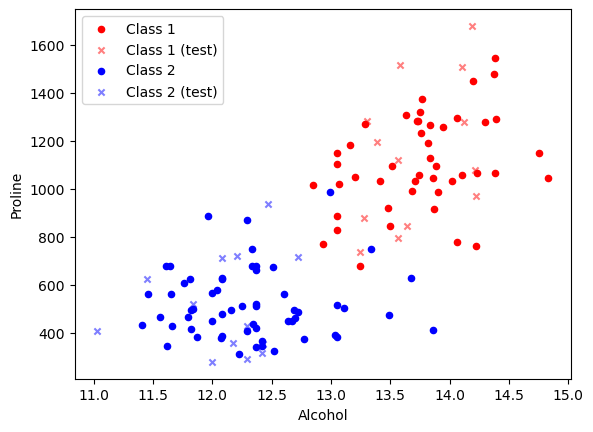

In [227]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

x_col = "Alcohol"
y_col = "Proline"

colors = {1: "red", 
          2: "blue"}

train_marker = "o"
test_marker = "x"

for class_label in [1, 2]:
    train_class = train_df[train_df["Class"] == class_label]
    test_class = test_df[test_df["Class"] == class_label]
    
    train_class.plot.scatter(x=x_col, 
                         y=y_col, 
                         ax=ax,
                         color=colors[class_label], 
                         marker=train_marker, 
                         label=f"Class {class_label}")
    
    test_class.plot.scatter(x=x_col, 
                        y=y_col, 
                        ax=ax,
                        color=colors[class_label], 
                        marker=test_marker, 
                        label=f"Class {class_label} (test)", 
                        alpha=0.5)
    
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)    
ax.legend()
plt.show()
    

## 3.4 Task: Implement OLS classifier

In [228]:
df_binary = df_original[df_original["Class"] != 3].copy()
df_binary["Class"] = df_binary["Class"].replace({1: -1, 2: 1})

df_binary.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,-1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,-1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,-1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,-1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,-1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [229]:
print(df_binary["Class"].value_counts())

Class
 1    71
-1    59
Name: count, dtype: int64


In [230]:
features = ["Alcohol", "Proline"]

X = df_binary[features].to_numpy()
Y = df_binary["Class"].to_numpy()

X_train = train_df[features].to_numpy()
Y_train = train_df["Class"].to_numpy()

X_test = test_df[features].to_numpy()
Y_test = test_df["Class"].to_numpy()

print('Data split as follows:')
print(f'  Training data samples: {len(train_df)}')
print(f'      Test data samples: {len(test_df)}')


Data split as follows:
  Training data samples: 104
      Test data samples: 26


In [231]:
print(X_train.shape)
print(Y_train.shape)

print(X_test.shape)
print(Y_test.shape)

(104, 2)
(104,)
(26, 2)
(26,)


In [232]:
class LinearBinaryClassification:
    """
    Linear binary classification class.

    Stores a linear classification model with parameters (w,b)
    and decision function h(x) = sign(w @ x + b)

    Parameters:
    ----------
    w: array
    b: array

    """
    def __init__(self, w, b):
        self.w = w
        self.b = b
        
    def __call__(self, x):
        # Numpy's `where` function provides a fast substitution
        return np.where(x @ self.w + self.b >= 0.0, 1, -1)

# Ordinary Least Squares (OLS) classifier

class OLSClassifier(LinearBinaryClassification):
    
        def fit(self, X, Y): 
                X_b = np.column_stack([X, np.ones(X.shape[0])]) # Add bias term to X
           
                w_tilde = np.linalg.lstsq(X_b, Y, rcond=None)[0] # Solve for w_tilde using least squares
        
                self.w = w_tilde[:-1]  # Extract weights
                self.b = w_tilde[-1]   # Extract bias term
                
                return self.w, self.b    

In [233]:
model = OLSClassifier(None, None)

model.fit(X_train, Y_train)

print(model.w)
print(model.b)

Y_pred = model(X_test)
accuracy = np.mean(Y_pred == Y_test)

print(accuracy)

[-0.20474833 -0.00087488]
4.892313316124419
0.5


In [234]:
print(Y_test)
print(Y_pred)

print(train_df["Class"].value_counts())
print(test_df["Class"].value_counts())

[1 1 1 1 2 1 2 2 2 1 2 1 2 1 2 2 1 2 2 2 1 1 2 1 2 1]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Class
2    58
1    46
Name: count, dtype: int64
Class
1    13
2    13
Name: count, dtype: int64


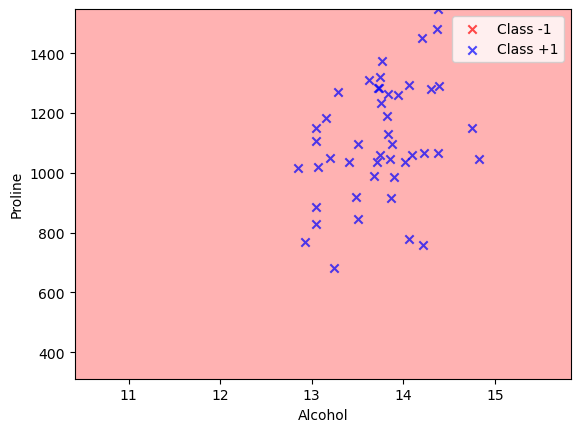

In [235]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots()

# compute how large the mesh for the contour plot shall be (with +/- 1 as
# safety bleed)
x1_min = X_train[:, 0].min() - 1
x1_max = X_train[:, 0].max() + 1
x2_min = X_train[:, 1].min() - 1
x2_max = X_train[:, 1].max() + 1

# compute grid for contour plot
x1_grid, x2_grid = np.meshgrid(np.linspace(x1_min, x1_max, 300), 
                               np.linspace(x2_min, x2_max, 300))
# meshgrid produces two arrays of the size `len(np.arange(x1_min, x1_max,
# .01))` times `len(np.arange(x2_min, x2_max, .01))` so that computations can
# be easily be vectorized.
X_grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
# present X_list to our hypothesis for evaluation
h = model(X_grid)
h_grid = h.ravel().reshape(x1_grid.shape)

cmap = mcolors.ListedColormap(['red', 'blue'])
plt.contourf(x1_grid, x2_grid, h_grid, cmap=cmap, alpha=.3)

plt.scatter(X_train[Y_train == -1, 0], X_train[Y_train == -1, 1], marker='x', color='red', label='Class -1', alpha=.7)
plt.scatter(X_train[Y_train == 1, 0], X_train[Y_train == 1, 1], marker='x', color='blue', label='Class +1', alpha=.7)

plt.xlabel(x_col)
plt.xlim(x1_min, x1_max)
plt.ylabel(y_col)
plt.ylim(x2_min, x2_max)
plt.legend()


In [236]:
N = len(X_train)
train_errors = np.sum(model(X_train) != Y_train)
print(f'Sample size: {N}')
print(f'Number of correct classifications: {N - train_errors}')
print(f'Number of incorrect classifications: {train_errors}')

Sample size: 104
Number of correct classifications: 46
Number of incorrect classifications: 58


In [237]:
def accuracy(y_pred,y_true):
    return (np.sum(y_pred == y_true)/y_true.size)*100

print(f"Train accuracy: {accuracy(model(X_train),Y_train)}")
print(f"Test accuracy: {accuracy(model(X_test),Y_test)}")

Train accuracy: 44.230769230769226
Test accuracy: 50.0


In [238]:

X = df_binary.drop(columns="Class").to_numpy()
Y = df_binary["Class"].to_numpy()

X_train_full = train_df.drop(columns="Class").to_numpy()
Y_train_full = train_df["Class"].to_numpy()

X_test_full = test_df.drop(columns="Class").to_numpy()
Y_test_full = test_df["Class"].to_numpy()

print('Data split as follows:')
print(f'  Training data samples: {len(train_df)}')
print(f'      Test data samples: {len(test_df)}')



Data split as follows:
  Training data samples: 104
      Test data samples: 26


In [239]:
model_full = OLSClassifier(None, None)
model_full.fit(X_train_full, Y_train_full)

(array([-0.14276539, -0.04048611, -0.25467151,  0.0313657 , -0.00055031,
         0.1426894 , -0.1223723 ,  0.16816759,  0.04995281,  0.00501227,
         0.07549526, -0.14432577, -0.0007152 ]),
 np.float64(4.228181214066753))

In [240]:
print(f"Train accuracy: {accuracy(model_full(X_train_full), Y_train_full):.2f}%")
print(f"Test accuracy: {accuracy(model_full(X_test_full), Y_test_full):.2f}%")

Train accuracy: 44.23%
Test accuracy: 50.00%


In [241]:
N = len(X_train_full)

train_errors = np.sum(model_full(X_train_full) != Y_train_full)

print(f"Sample size: {N}")
print(f"Number of correct classifications: {N - train_errors}")
print(f"Number of incorrect classifications: {train_errors}")

Sample size: 104
Number of correct classifications: 46
Number of incorrect classifications: 58


In [242]:
print(df_binary["Class"].value_counts())
print(train_df["Class"].value_counts())
print(test_df["Class"].value_counts())

Class
 1    71
-1    59
Name: count, dtype: int64
Class
2    58
1    46
Name: count, dtype: int64
Class
1    13
2    13
Name: count, dtype: int64


In [243]:
df_binary = df_original[df_original["Class"] != 3].copy()
df_binary["Class"] = df_binary["Class"].replace({1: -1, 2: 1})

train_df, test_df = train_test_split(
    df_binary,
    train_size=0.8,
    random_state=42
)

In [244]:
X_train_full = train_df.drop(columns="Class").to_numpy()
Y_train_full = train_df["Class"].to_numpy()

X_test_full = test_df.drop(columns="Class").to_numpy()
Y_test_full = test_df["Class"].to_numpy()

In [246]:
model_full = OLSClassifier(None, None)
model_full.fit(X_train_full, Y_train_full)

(array([-0.28553078, -0.08097222, -0.50934302,  0.06273141, -0.00110061,
         0.28537879, -0.24474459,  0.33633518,  0.09990562,  0.01002454,
         0.15099053, -0.28865153, -0.00143039]),
 np.float64(5.456362428133506))

In [247]:
print(f"Train accuracy: {accuracy(model_full(X_train_full), Y_train_full):.2f}%")
print(f"Test accuracy: {accuracy(model_full(X_test_full), Y_test_full):.2f}%")

Train accuracy: 100.00%
Test accuracy: 100.00%
